# DSCI 552 — Homework 2

**Name:** Gina Mao  
**GitHub Username:** ruoxuanm116  
**USC ID:** 8885483334

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)
RANDOM_STATE = 42

## 1. Combined Cycle Power Plant Data Set

### (a) Download the data
The data were downloaded from the UCI repository and stored at `../data/CCPP/Folds5x2_pp.xlsx`.
The file has five sheets that are shuffled versions of the same data; as instructed, we work with **Sheet1**.

In [2]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
predictors = ['AT', 'V', 'AP', 'RH']
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data
#### (b) i. Number of rows and columns

In [3]:
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])
print('Missing values   :', df.isna().sum().sum())
df.info()

Number of rows   : 9568
Number of columns: 5
Missing values   : 0
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


**Answer.** The data set has **9568 rows** and **5 columns**, with no missing values.

* **Rows**: each row is one observation — the hourly averaged ambient conditions and the net hourly electrical energy output of the power plant, for one hour while it ran at full load (2006–2011).
* **Columns**:
  * `AT` — ambient Temperature (°C) — predictor
  * `V` — Exhaust Vacuum (cm Hg) — predictor
  * `AP` — ambient Pressure (millibar) — predictor
  * `RH` — Relative Humidity (%) — predictor
  * `PE` — net hourly electrical energy output (MW) — **response**

#### (b) ii. Pairwise scatterplots

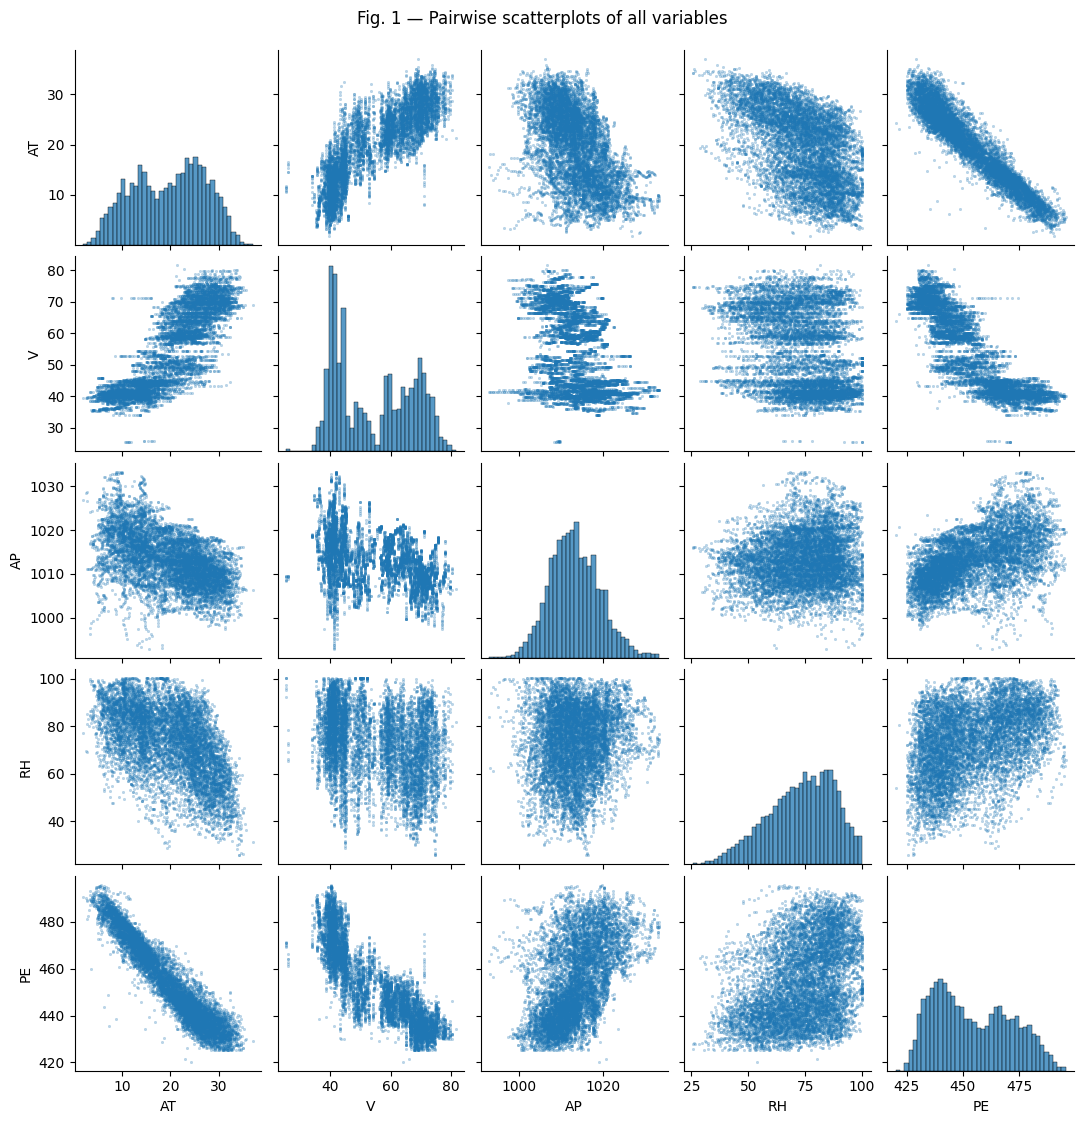

In [4]:
g = sns.pairplot(df, plot_kws={'s': 4, 'alpha': 0.3, 'edgecolor': None}, diag_kws={'bins': 40}, height=2.2)
g.fig.suptitle('Fig. 1 — Pairwise scatterplots of all variables', y=1.02)
plt.show()

In [5]:
df.corr().round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


**Findings.**

* **AT vs PE**: very strong, almost linear **negative** relationship (r ≈ −0.95). Higher ambient temperature → lower energy output. The cloud bends slightly, hinting at mild curvature.
* **V vs PE**: strong **negative** relationship (r ≈ −0.87), but noisier than AT, with vertical bands at certain vacuum levels.
* **AP vs PE**: moderate **positive** relationship (r ≈ 0.52) with a lot of scatter.
* **RH vs PE**: weak **positive** relationship (r ≈ 0.39); the points are widely scattered.
* **Among predictors**: AT and V are strongly positively correlated (r ≈ 0.84), and AT is moderately negatively correlated with AP and RH (≈ −0.5). So there is collinearity among predictors, which matters when we fit the multiple regression.
* The histograms show AT and V are roughly bimodal, AP is roughly bell-shaped, and RH is left-skewed (many values near 100%).

#### (b) iii. Summary statistics

In [6]:
summary = pd.DataFrame({
    'Mean':   df.mean(),
    'Median': df.median(),
    'Min':    df.min(),
    'Max':    df.max(),
    'Range':  df.max() - df.min(),
    'Q1':     df.quantile(0.25),
    'Q3':     df.quantile(0.75),
})
summary['IQR'] = summary['Q3'] - summary['Q1']
summary.round(3)

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


### (c) Simple linear regression for each predictor

In [7]:
simple_models = {}
rows = []
for p in predictors:
    m = smf.ols(f'PE ~ {p}', data=df).fit()
    simple_models[p] = m
    rows.append({'Predictor': p,
                 'Intercept': m.params['Intercept'],
                 'Slope': m.params[p],
                 'Std. error': m.bse[p],
                 't-stat': m.tvalues[p],
                 'p-value': m.pvalues[p],
                 'R^2': m.rsquared,
                 'RSE': np.sqrt(m.scale)})
simple_table = pd.DataFrame(rows).set_index('Predictor')
simple_table.round(4)

,Intercept,Slope,Std. error,t-stat,p-value,R^2,RSE
Predictor,,,,,,,
AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,5.4257
V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,8.4220
AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,14.5951
RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,15.7179


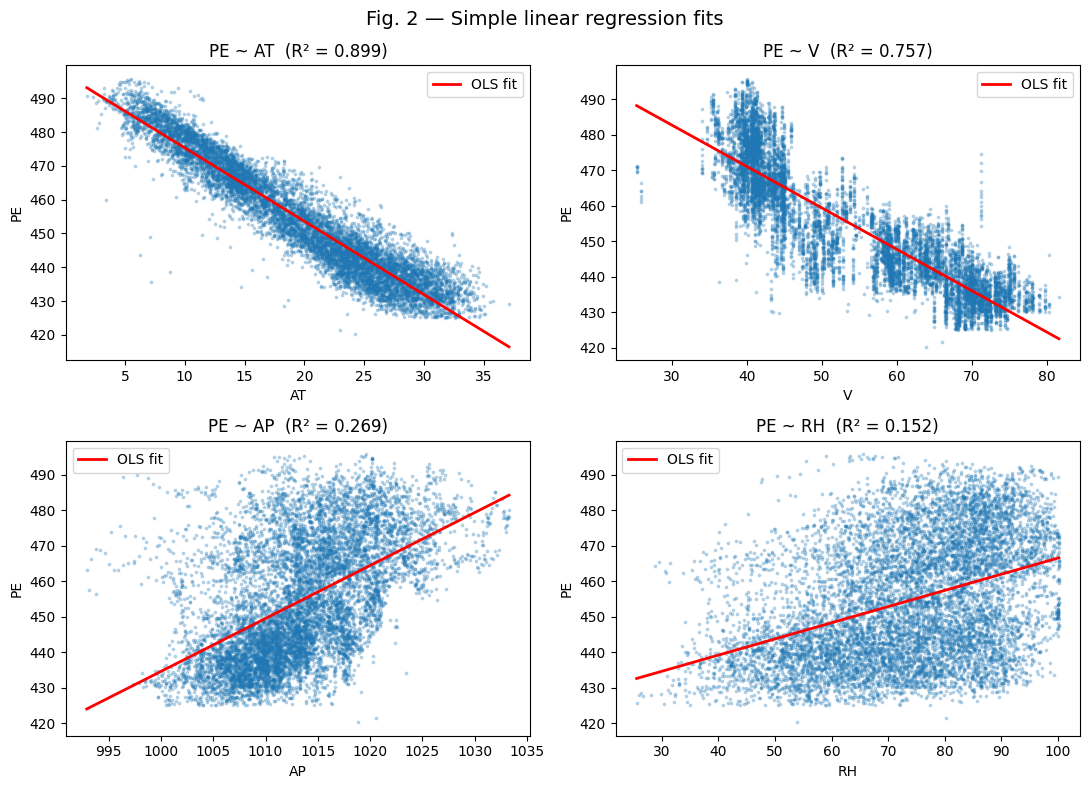

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), predictors):
    m = simple_models[p]
    ax.scatter(df[p], df['PE'], s=3, alpha=0.25)
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(xs, m.params['Intercept'] + m.params[p] * xs, color='red', lw=2, label='OLS fit')
    ax.set_xlabel(p); ax.set_ylabel('PE')
    ax.set_title(f'PE ~ {p}  (R² = {m.rsquared:.3f})')
    ax.legend()
fig.suptitle('Fig. 2 — Simple linear regression fits', fontsize=14)
plt.tight_layout(); plt.show()

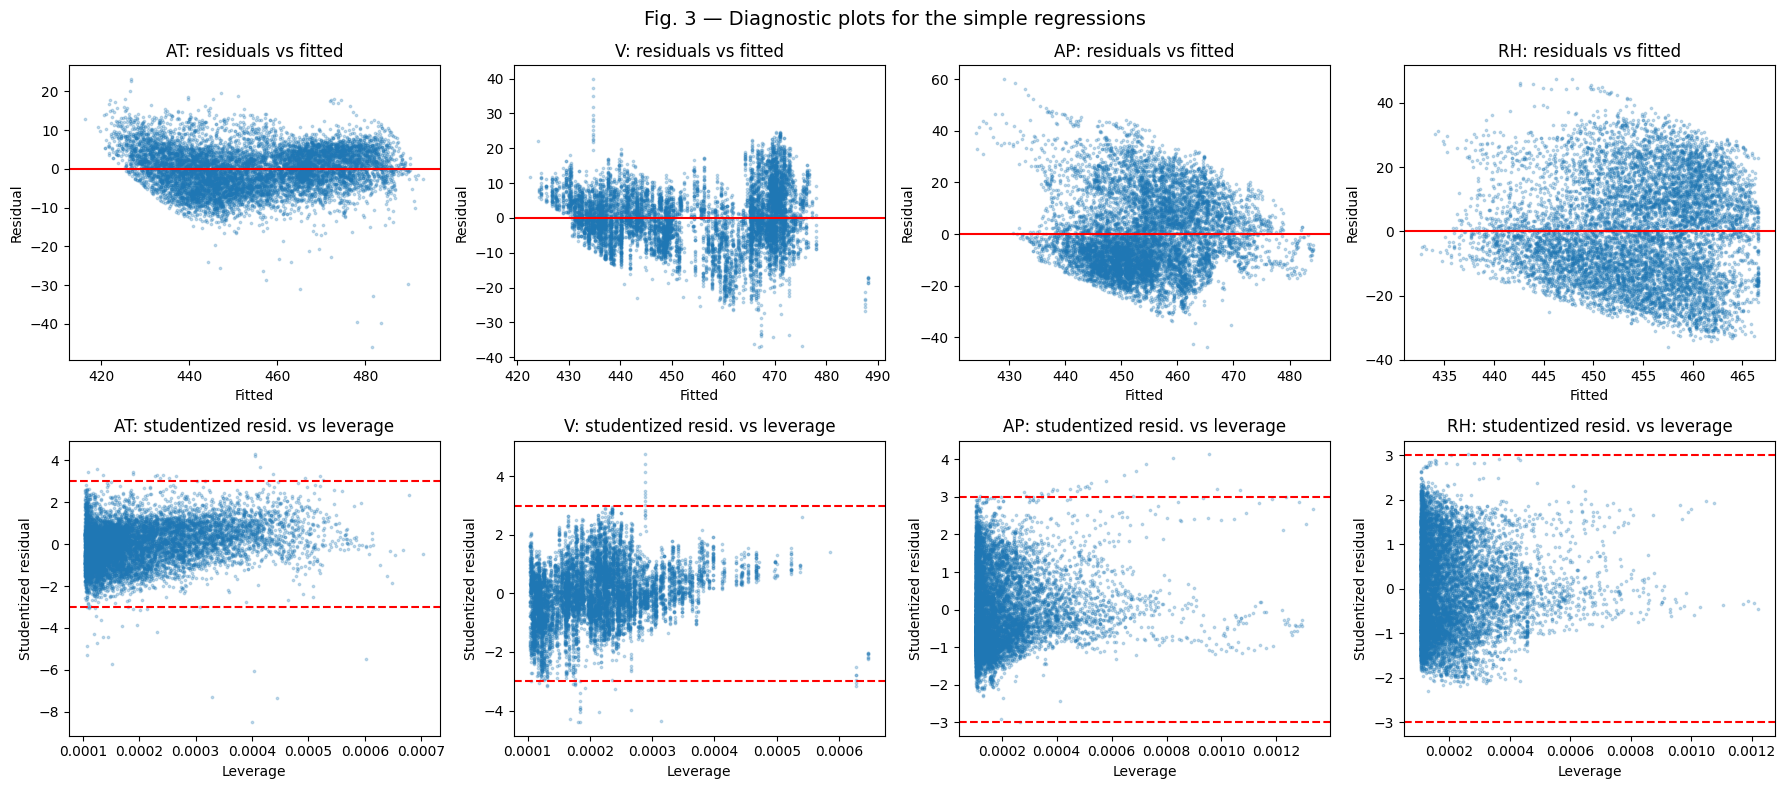

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, p in enumerate(predictors):
    m = simple_models[p]
    axes[0, j].scatter(m.fittedvalues, m.resid, s=3, alpha=0.25)
    axes[0, j].axhline(0, color='red')
    axes[0, j].set_title(f'{p}: residuals vs fitted'); axes[0, j].set_xlabel('Fitted'); axes[0, j].set_ylabel('Residual')
    infl = m.get_influence()
    axes[1, j].scatter(infl.hat_matrix_diag, infl.resid_studentized_external, s=3, alpha=0.25)
    axes[1, j].axhline(3, color='red', ls='--'); axes[1, j].axhline(-3, color='red', ls='--')
    axes[1, j].set_title(f'{p}: studentized resid. vs leverage'); axes[1, j].set_xlabel('Leverage'); axes[1, j].set_ylabel('Studentized residual')
fig.suptitle('Fig. 3 — Diagnostic plots for the simple regressions', fontsize=14)
plt.tight_layout(); plt.show()

In [10]:
# Outlier / influence check: |studentized residual| > 3, and Cook's distance
rows = []
for p in predictors:
    m = simple_models[p]
    infl = m.get_influence()
    sr = infl.resid_studentized_external
    cook = infl.cooks_distance[0]
    out = np.abs(sr) > 3
    m_clean = smf.ols(f'PE ~ {p}', data=df[~out]).fit()
    rows.append({'Predictor': p, '# |stud. resid| > 3': out.sum(),
                 "max Cook's D": cook.max(),
                 'Slope (all data)': m.params[p], 'Slope (outliers removed)': m_clean.params[p],
                 'R^2 (all)': m.rsquared, 'R^2 (outliers removed)': m_clean.rsquared})
pd.DataFrame(rows).set_index('Predictor').round(4)

,# |stud. resid| > 3,max Cook's D,Slope (all data),Slope (outliers removed),R^2 (all),R^2 (outliers removed)
Predictor,,,,,,
AT,42,0.0143,-2.1713,-2.1802,0.8989,0.9064
V,33,0.0032,-1.1681,-1.1769,0.7565,0.7670
AP,30,0.0082,1.4899,1.5401,0.2688,0.2864
RH,2,0.0021,0.4557,0.4564,0.1519,0.1526


**Answer.**

* All four simple regressions have a p-value for the slope that is essentially 0 (far below 0.05), so **every predictor (AT, V, AP, RH) has a statistically significant association with PE** when considered alone. With n = 9568 even weak associations are significant, so the strength is better judged by R²:
  * **AT**: slope ≈ −2.17 MW per °C, R² ≈ 0.90 — the best single predictor.
  * **V**: slope ≈ −1.17, R² ≈ 0.76.
  * **AP**: slope ≈ +1.49, R² ≈ 0.27.
  * **RH**: slope ≈ +0.46, R² ≈ 0.15.
* Fig. 2 supports this: AT and V follow the fitted line closely, while AP and RH have large scatter around the line. The residual plots in Fig. 3 show some curvature for AT and V (a hint of nonlinearity, examined in (f)).
* **Outliers.** Points with |studentized residual| > 3 are potential outliers: there are 42 (AT), 33 (V), 30 (AP) and 2 (RH) of them — well under 1% of the data. However, the largest Cook's distance is at most ≈ 0.014 (far below the usual threshold of 1), and all leverages are small, so **none of these points is influential**. Refitting without them barely changes the slopes. Because these readings are plausible physical measurements and removing them does not change the conclusions, **I would not remove any outliers** (removing them would only artificially shrink the error estimates).

### (d) Multiple linear regression with all predictors

In [11]:
multi = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:07:53   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Answer.** The multiple regression model is

PE ≈ 454.61 − 1.978·AT − 0.234·V + 0.062·AP − 0.158·RH

* R² ≈ **0.929** (higher than any single-predictor model), and the F-statistic ≈ 31,140 with p ≈ 0, so at least one predictor is associated with the response.
* The p-values of all four coefficients are < 0.001 (AT: t ≈ −129, V: t ≈ −32, AP: t ≈ 6.6, RH: t ≈ −38), so **we can reject H₀: βⱼ = 0 for all four predictors — AT, V, AP and RH**.
* The large condition number warns of collinearity (mostly between AT and V), which affects the size of the individual coefficients but not their significance here.

### (e) Comparing simple and multiple regression coefficients

,Simple regression (1c),Multiple regression (1d)
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


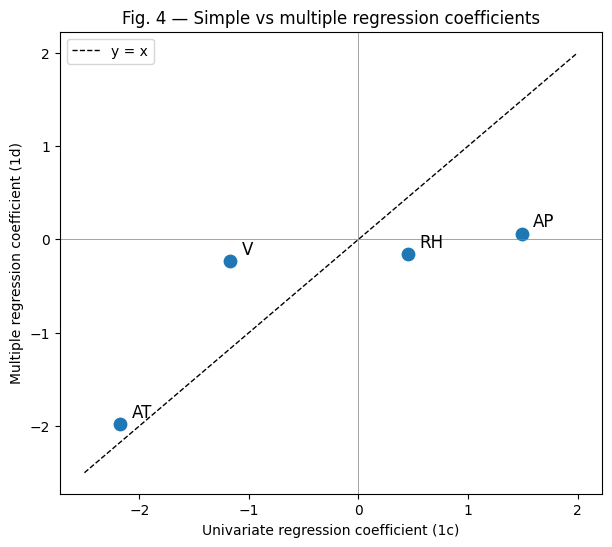

In [12]:
coef_cmp = pd.DataFrame({'Simple regression (1c)': [simple_models[p].params[p] for p in predictors],
                         'Multiple regression (1d)': [multi.params[p] for p in predictors]},
                        index=predictors)
display(coef_cmp.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coef_cmp.iloc[:, 0], coef_cmp.iloc[:, 1], s=80, color='tab:blue')
for p in predictors:
    ax.annotate(p, (coef_cmp.loc[p].iloc[0], coef_cmp.loc[p].iloc[1]), textcoords='offset points', xytext=(8, 5), fontsize=12)
lim = [-2.5, 2.0]
ax.plot(lim, lim, 'k--', lw=1, label='y = x')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Univariate regression coefficient (1c)')
ax.set_ylabel('Multiple regression coefficient (1d)')
ax.set_title('Fig. 4 — Simple vs multiple regression coefficients')
ax.legend(); plt.show()

**Answer.** In (c) all predictors were significant, and in (d) they are all still significant, but the coefficients change a lot:

* **AT** barely changes (−2.17 → −1.98): it is the dominant predictor, so its effect is almost the same with or without the others.
* **V** shrinks from −1.17 to −0.23: much of V's apparent effect in the simple regression is really the effect of AT (they are correlated, r ≈ 0.84).
* **AP** shrinks from +1.49 to +0.06, for the same reason (AP is negatively correlated with AT).
* **RH** changes **sign**, from +0.46 to −0.16. Alone, RH looks positively related to PE only because high humidity tends to happen at low temperatures; holding AT (and the others) fixed, higher humidity slightly lowers output.

So the simple regressions mix the effect of a predictor with the effects of the predictors correlated with it; the multiple regression gives each predictor's effect holding the others fixed. In Fig. 4 only AT lies near the y = x line.

### (f) Nonlinear association: Y = β₀ + β₁X + β₂X² + β₃X³ + ε
The predictors are mean-centered before building the polynomial terms. Otherwise AP³ (≈ 10⁹) makes the design matrix numerically rank-deficient. Centering does not change the fitted values or the p-value of the highest-order term.

In [13]:
dfc = df.copy()
dfc[predictors] = dfc[predictors] - dfc[predictors].mean()
rows = []
for p in predictors:
    m = smf.ols(f'PE ~ {p} + I({p}**2) + I({p}**3)', data=dfc).fit()
    rows.append({'Predictor': p,
                 'p(X)': m.pvalues[p], 'p(X^2)': m.pvalues[f'I({p} ** 2)'], 'p(X^3)': m.pvalues[f'I({p} ** 3)'],
                 'R^2 linear': simple_models[p].rsquared, 'R^2 cubic': m.rsquared})
poly_table = pd.DataFrame(rows).set_index('Predictor')
poly_table.style.format({'p(X)': '{:.2e}', 'p(X^2)': '{:.2e}', 'p(X^3)': '{:.2e}', 'R^2 linear': '{:.4f}', 'R^2 cubic': '{:.4f}'})

,p(X),p(X^2),p(X^3),R^2 linear,R^2 cubic
Predictor,,,,,
AT,0.00e+00,3.31e-231,3.65e-110,0.8989,0.9119
V,0.00e+00,8.98e-131,1.37e-02,0.7565,0.7750
AP,0.00e+00,2.19e-46,2.12e-67,0.2688,0.2975
RH,9.65e-152,1.01e-01,1.44e-05,0.1519,0.1537


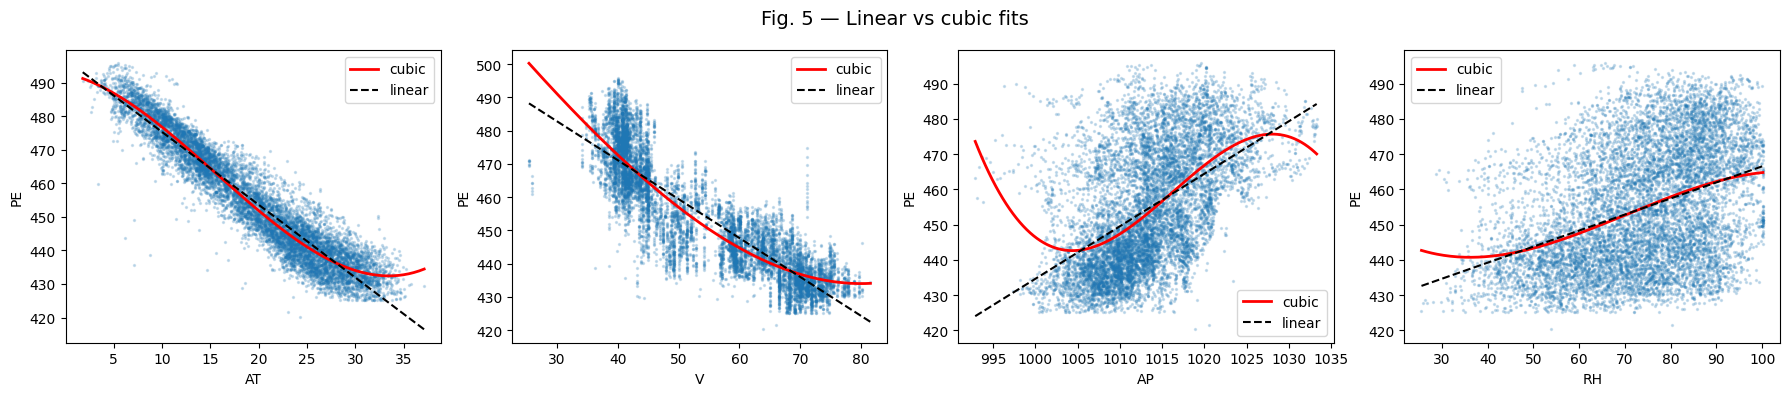

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, p in zip(axes, predictors):
    m = smf.ols(f'PE ~ {p} + I({p}**2) + I({p}**3)', data=dfc).fit()
    xs = np.linspace(dfc[p].min(), dfc[p].max(), 200)
    ax.scatter(df[p], df['PE'], s=2, alpha=0.2)
    ax.plot(xs + df[p].mean(), m.predict(pd.DataFrame({p: xs})), color='red', lw=2, label='cubic')
    ax.plot(xs + df[p].mean(), simple_models[p].predict(pd.DataFrame({p: xs + df[p].mean()})), 'k--', lw=1.5, label='linear')
    ax.set_xlabel(p); ax.set_ylabel('PE'); ax.legend()
fig.suptitle('Fig. 5 — Linear vs cubic fits', fontsize=14)
plt.tight_layout(); plt.show()

**Answer.** Yes, there is evidence of nonlinear association:

* **AT**: both X² and X³ are highly significant (p ≈ 0), and R² rises from 0.899 to 0.912 — clear nonlinearity.
* **V**: X² is highly significant and X³ is significant at the 5% level (p ≈ 0.014); R² rises from 0.757 to 0.775.
* **AP**: X² and X³ are highly significant; R² rises from 0.269 to 0.298.
* **RH**: X³ is significant (p ≈ 10⁻⁵), X² is not (p ≈ 0.10); R² only changes from 0.152 to 0.154. So the nonlinearity for RH is statistically significant but practically very small.

Because n is large, small curvature becomes significant; the curvature matters most in practice for AT, V and AP.

### (g) Full model with all pairwise interaction terms

In [15]:
inter_model = smf.ols('PE ~ (AT + V + AP + RH)**2', data=df).fit()
print(inter_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:07:54   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [16]:
inter_terms = [t for t in inter_model.params.index if ':' in t]
pd.DataFrame({'coef': inter_model.params[inter_terms], 'p-value': inter_model.pvalues[inter_terms],
              'significant (α = 0.05)': inter_model.pvalues[inter_terms] < 0.05}).round(4)

,coef,p-value,significant (α = 0.05)
AT:V,0.0210,0.0000,True
AT:AP,0.0018,0.4521,False
AT:RH,-0.0052,0.0000,True
V:AP,0.0068,0.0000,True
V:RH,0.0008,0.0862,False
AP:RH,-0.0016,0.0336,True


**Answer.** At the 5% level, the interaction terms **AT:V (p ≈ 0), AT:RH (p ≈ 0), V:AP (p ≈ 0) and AP:RH (p ≈ 0.034)** are statistically significant. **AT:AP (p ≈ 0.45)** and **V:RH (p ≈ 0.09)** are not. R² increases from 0.929 (additive model) to 0.936, so there is evidence that some interactions are associated with the response, with AT:V by far the strongest (t ≈ 23).

### (h) Improving the model with interactions and quadratic terms
* 70% / 30% random train/test split (`random_state = 42`).
* **Model 1**: linear regression with all four predictors.
* **Model 2**: all main effects + all 6 pairwise interactions + all 4 quadratic terms, then **backward elimination by p-value** (remove the least significant term with p > 0.05, refit, repeat). To respect the hierarchy principle (be careful about interaction terms), a main effect is never removed while it still appears in an interaction or quadratic term in the model.
* The predictors are centered using the **training** means before building Model 2 (to reduce collinearity between X, X² and X·Z). The test set is centered with the same means.

In [17]:
train, test = train_test_split(df, test_size=0.3, random_state=RANDOM_STATE)
print('Train size:', len(train), '| Test size:', len(test))

def mse(model, data):
    return mean_squared_error(data['PE'], model.predict(data))

# Model 1: all predictors, linear
lin_model = smf.ols('PE ~ AT + V + AP + RH', data=train).fit()
print(f'Model 1 (linear)  train MSE = {mse(lin_model, train):.4f}   test MSE = {mse(lin_model, test):.4f}')

Train size: 6697 | Test size: 2871
Model 1 (linear)  train MSE = 20.5808   test MSE = 21.2399


In [18]:
mu = train[predictors].mean()
train_c, test_c = train.copy(), test.copy()
train_c[predictors] = train_c[predictors] - mu
test_c[predictors] = test_c[predictors] - mu

all_terms = (predictors
             + [f'{a}:{b}' for a, b in itertools.combinations(predictors, 2)]
             + [f'I({p} ** 2)' for p in predictors])

def parents(term):
    # main effects that a higher-order term depends on
    if ':' in term:
        return term.split(':')
    if term.startswith('I('):
        return [term[2:term.index(' ')]]
    return []

terms = all_terms[:]
full_poly = smf.ols('PE ~ ' + ' + '.join(terms), data=train_c).fit()
print(f'Full model (all interactions + quadratics, before elimination): '
      f'train MSE = {mse(full_poly, train_c):.4f}   test MSE = {mse(full_poly, test_c):.4f}\n')

while True:
    model = smf.ols('PE ~ ' + ' + '.join(terms), data=train_c).fit()
    pv = model.pvalues.drop('Intercept')
    protected = set(itertools.chain.from_iterable(parents(t) for t in terms))
    candidates = pv[[t for t in pv.index if t not in protected]]
    if candidates.max() <= 0.05:
        break
    worst = candidates.idxmax()
    print(f'Removing {worst:12s} (p = {candidates.max():.4f})')
    terms.remove(worst)

reduced_model = model
print('\nFinal terms:', terms)
print(reduced_model.summary())

Full model (all interactions + quadratics, before elimination): train MSE = 17.8878   test MSE = 18.6473

Removing V:RH         (p = 0.8674)
Removing I(V ** 2)    (p = 0.6077)
Removing V:AP         (p = 0.3578)

Final terms: ['AT', 'V', 'AP', 'RH', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH', 'I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)']
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:07:54   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11     

In [19]:
h_results = pd.DataFrame({
    'Train MSE': [mse(lin_model, train), mse(reduced_model, train_c)],
    'Test MSE':  [mse(lin_model, test),  mse(reduced_model, test_c)]},
    index=['Model 1: linear (all predictors)', 'Model 2: interactions + quadratics (reduced)'])
h_results.round(4)

,Train MSE,Test MSE
Model 1: linear (all predictors),20.5808,21.2399
Model 2: interactions + quadratics (reduced),17.8908,18.6600


**Answer.** Backward elimination removed **V:RH**, **V²** and **V:AP** (in that order). The final model keeps AT, V, AP, RH, AT:V, AT:AP, AT:RH, AP:RH, AT², AP², RH², and all remaining terms have p < 0.05.

| Model | Train MSE | Test MSE |
|---|---|---|
| Model 1: linear, all predictors | ≈ 20.58 | ≈ 21.24 |
| Model 2: interactions + quadratics (reduced) | ≈ 17.89 | ≈ 18.66 |

**Yes, the model can be improved**: including the significant interaction and quadratic terms lowers the test MSE by about 12% (21.24 → 18.66). The train and test errors stay close, so the richer model is not overfitting. (The full model before elimination has almost the same test MSE, ≈ 18.65, so the removed terms were not useful.)

### (i) KNN Regression
#### (i) i. Raw vs normalized features, k ∈ {1, …, 100}
We use the same 70/30 split as in (h). For the normalized features, a `StandardScaler` (z-score) is fit on the training set only and then applied to the test set. The "best" k is the one with the **lowest test MSE**.

In [20]:
X_train, X_test = train[predictors].values, test[predictors].values
y_train, y_test = train['PE'].values, test['PE'].values
scaler = StandardScaler().fit(X_train)
feature_sets = {'Raw': (X_train, X_test),
                'Normalized': (scaler.transform(X_train), scaler.transform(X_test))}

ks = np.arange(1, 101)
knn_errors = {}
for name, (Xtr, Xte) in feature_sets.items():
    tr_err, te_err = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_train)
        tr_err.append(mean_squared_error(y_train, knn.predict(Xtr)))
        te_err.append(mean_squared_error(y_test, knn.predict(Xte)))
    knn_errors[name] = (np.array(tr_err), np.array(te_err))

best = {}
for name, (tr_err, te_err) in knn_errors.items():
    i = np.argmin(te_err)
    best[name] = {'best k': ks[i], 'Train MSE': tr_err[i], 'Test MSE': te_err[i]}
pd.DataFrame(best).T.astype({'best k': int})

,best k,Train MSE,Test MSE
Raw,5,10.600769,15.726820
Normalized,4,8.591433,14.305669


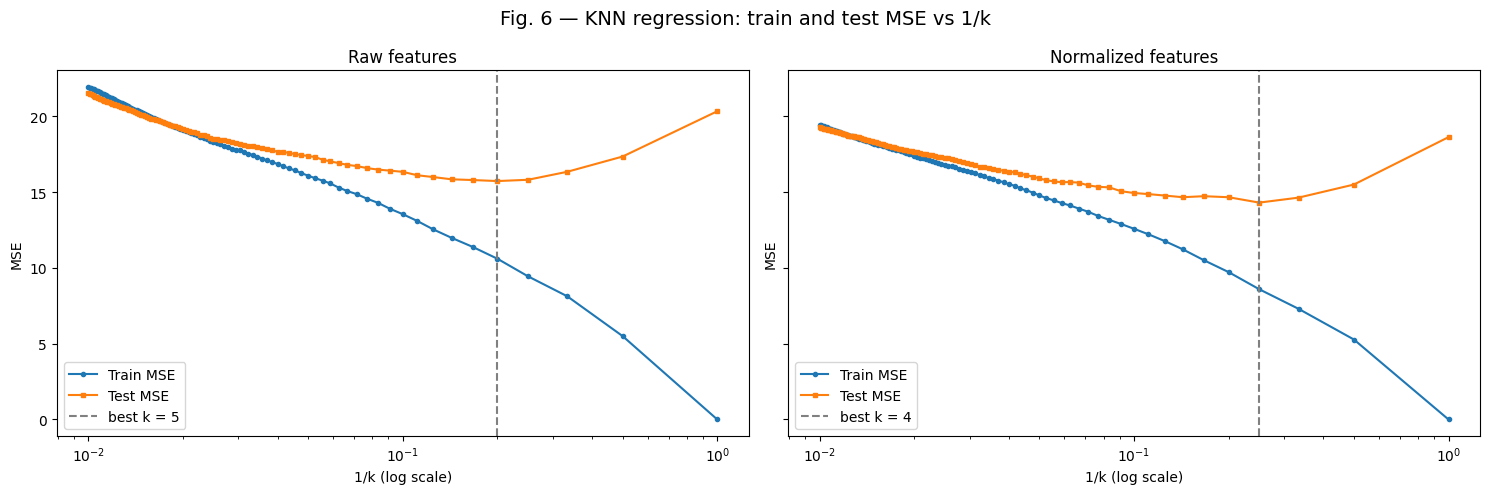

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, (tr_err, te_err)) in zip(axes, knn_errors.items()):
    ax.plot(1 / ks, tr_err, 'o-', ms=3, label='Train MSE')
    ax.plot(1 / ks, te_err, 's-', ms=3, label='Test MSE')
    kb = best[name]['best k']
    ax.axvline(1 / kb, color='grey', ls='--', label=f'best k = {kb}')
    ax.set_xscale('log')
    ax.set_xlabel('1/k (log scale)'); ax.set_ylabel('MSE')
    ax.set_title(f'{name} features')
    ax.legend()
fig.suptitle('Fig. 6 — KNN regression: train and test MSE vs 1/k', fontsize=14)
plt.tight_layout(); plt.show()

**Answer.**

* **Raw features**: best k = **5**, train MSE ≈ 10.60, test MSE ≈ **15.73**.
* **Normalized features**: best k = **4**, train MSE ≈ 8.59, test MSE ≈ **14.31**.

Fig. 6 shows the usual bias–variance trade-off. As 1/k grows (k gets smaller, the model gets more flexible), the training error drops to 0 at k = 1. The test error is U-shaped: it falls as k decreases and then rises again for very small k because of overfitting. Normalizing helps because, with raw features, the distance is dominated by the variables with the largest spread (RH and V) and AT — the most important predictor — gets relatively less weight.

### (j) KNN vs the best linear regression model

In [22]:
compare = pd.DataFrame({
    'Train MSE': [mse(lin_model, train), mse(reduced_model, train_c), best['Raw']['Train MSE'], best['Normalized']['Train MSE']],
    'Test MSE':  [mse(lin_model, test),  mse(reduced_model, test_c),  best['Raw']['Test MSE'],  best['Normalized']['Test MSE']]},
    index=['Linear (all predictors)', 'Linear + interactions + quadratics (reduced)',
           f"KNN raw (k={best['Raw']['best k']})", f"KNN normalized (k={best['Normalized']['best k']})"])
compare.round(4)

,Train MSE,Test MSE
Linear (all predictors),20.5808,21.2399
Linear + interactions + quadratics (reduced),17.8908,18.6600
KNN raw (k=5),10.6008,15.7268
KNN normalized (k=4),8.5914,14.3057


**Answer.** The linear regression model with the smallest test error is Model 2 from (h) (interactions + quadratic terms), with test MSE ≈ 18.66. KNN with normalized features and k = 4 has a **lower test MSE (≈ 14.31)**, and even KNN on raw features (≈ 15.73) beats it.

* **Why KNN wins here:** n is large (6697 training points) and p is small (4), so there is no curse of dimensionality and each point has many close neighbors. KNN is non-parametric and can capture the nonlinear and interaction structure that we found in (f)–(g) without us having to specify it. Even with quadratic and interaction terms, the linear model still has some bias.
* **Trade-offs:** the linear model is much more interpretable (coefficients, p-values, direction of effects), is cheap to evaluate, and extrapolates more gracefully. KNN gives no interpretable coefficients, has to store the whole training set, needs feature scaling, and its larger gap between train and test error shows higher variance.
* **Conclusion:** if prediction accuracy is the goal, KNN with normalized features (k ≈ 4) is the better model for this data set. If understanding how each ambient variable affects output is the goal, the regression model with interactions and quadratic terms is more useful and still explains about 94% of the variance.

## 2. ISLR 2.4.1

For each case, is a flexible statistical learning method expected to perform better or worse than an inflexible one?

**(a) Sample size n extremely large, number of predictors p small → Better.**
With so much data, a flexible method can fit the true f closely without overfitting much; the extra variance is small because of the large n, while the reduction in bias is substantial.

**(b) Number of predictors p extremely large, n small → Worse.**
With few observations and many predictors, a flexible method will overfit the noise in the training data (high variance). An inflexible method (e.g. linear regression / a restricted model) has lower variance and will generalize better.

**(c) The relationship between the predictors and response is highly non-linear → Better.**
An inflexible (e.g. linear) method would have large bias because it cannot represent the nonlinearity; a flexible method has the degrees of freedom to capture it.

**(d) The variance of the error terms σ² = Var(ε) is extremely high → Worse.**
With very noisy data a flexible method would chase the noise (fit ε instead of f), increasing variance. An inflexible method is less sensitive to the noise and would perform better.

## 3. ISLR 2.4.7

Training data:

| Obs. | X1 | X2 | X3 | Y |
|---|---|---|---|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | −1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Test point: X1 = X2 = X3 = 0.

In [23]:
islr = pd.DataFrame({'X1': [0, 2, 0, 0, -1, 1], 'X2': [3, 0, 1, 1, 0, 1], 'X3': [0, 0, 3, 2, 1, 1],
                     'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']}, index=range(1, 7))
islr['Distance'] = np.sqrt((islr[['X1', 'X2', 'X3']] ** 2).sum(axis=1))
islr.sort_values('Distance').round(4)

,X1,X2,X3,Y,Distance
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321
2,2,0,0,Red,2.0000
4,0,1,2,Green,2.2361
1,0,3,0,Red,3.0000
3,0,1,3,Red,3.1623


**(a) Euclidean distances to the test point (0, 0, 0):**

| Obs. | Distance |
|---|---|
| 1 | √(0+9+0) = **3** |
| 2 | √(4+0+0) = **2** |
| 3 | √(0+1+9) = **√10 ≈ 3.162** |
| 4 | √(0+1+4) = **√5 ≈ 2.236** |
| 5 | √(1+0+1) = **√2 ≈ 1.414** |
| 6 | √(1+1+1) = **√3 ≈ 1.732** |

**(b) K = 1: Green.** The nearest neighbor is observation 5 (distance √2 ≈ 1.414), which is Green.

**(c) K = 3: Red.** The three nearest neighbors are observations 5 (Green, 1.414), 6 (Red, 1.732) and 2 (Red, 2). Two of the three are Red, so the prediction is Red.

**(d)** If the Bayes decision boundary is highly nonlinear, we expect the **best value of K to be small**. A small K gives a flexible decision boundary that can follow the nonlinear shape; a large K averages over many points and produces a smoother, closer-to-linear boundary, which would have high bias here.

## References
1. Pınar Tüfekci, *Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods*, International Journal of Electrical Power & Energy Systems, 60, 2014, 126–140.
2. UCI Machine Learning Repository — Combined Cycle Power Plant: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant
3. James, Witten, Hastie, Tibshirani, *An Introduction to Statistical Learning* (ISLR), Ch. 2–3.
4. statsmodels OLS / formula API: https://www.statsmodels.org/stable/regression.html
5. scikit-learn `KNeighborsRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
6. scikit-learn polynomial features: https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features